# Zadanie domowe #11 - Radosław Cacała

## Zadanie #1

r = 0.15999999999999998
[[0.         0.         0.         ... 0.         0.         0.        ]
 [0.1        0.1        0.1        ... 0.04773007 0.04754222 0.0473551 ]
 [0.2        0.2        0.2        ... 0.09428607 0.09391495 0.09354528]
 ...
 [0.2        0.2        0.2        ... 0.09428607 0.09391495 0.09354528]
 [0.1        0.1        0.1        ... 0.04773007 0.04754222 0.0473551 ]
 [0.         0.         0.         ... 0.         0.         0.        ]]


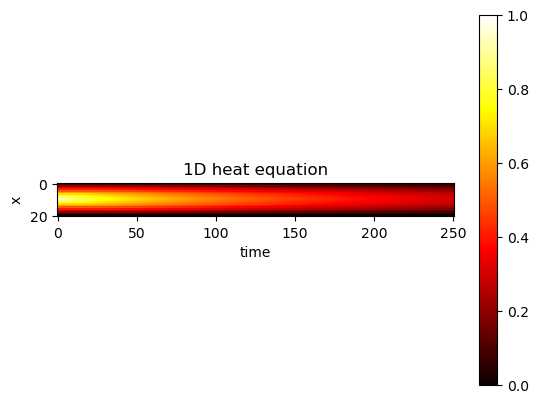

In [3]:
import math
import numpy as np
import matplotlib.pyplot as plt

D, Nx, Nt, L, T = 1.0, 20, 250, 1.0, 0.1

t = np.linspace(0, T, num=Nt+1, dtype=float)
x = np.linspace(0, L, num=Nx+1, dtype=float)

dx = x[1] - x[0]
dt = t[1] - t[0]

r = D * dt / (dx * dx)

print("r = {}".format(r))

assert r < 0.5

u = np.empty((Nx+1, Nt+1), dtype=float)

u[:,0] = np.where(x < 0.5, 2*x, 2*(1-x))

# oba końce zimne
u[0,:] = 0.0
u[Nx,:] = 0.0

for j in range(Nt):

    u[1:-1, j+1] = (
        r * u[:-2, j]
        + (1 - 2*r) * u[1:-1, j]
        + r * u[2:, j]
    )

print(u)

plt.title("1D heat equation")
plt.xlabel("time")
plt.ylabel("x")

plt.imshow(u,
           cmap='hot',
           interpolation='nearest')

plt.colorbar()

plt.show()

## Zadanie #2

r = 0.15999999999999998


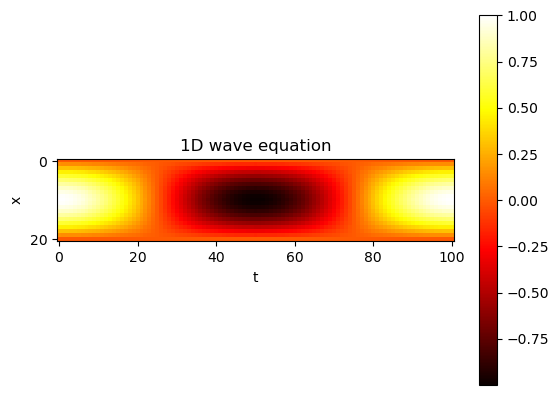

In [4]:
import math
import numpy as np
import matplotlib.pyplot as plt

Nx, Nt, L, T, c = 20, 100, 1.0, 2.0, 1.0

t = np.linspace(0, T, num=Nt+1, dtype=float)
x = np.linspace(0, L, num=Nx+1, dtype=float)

dx = x[1] - x[0]
dt = t[1] - t[0]

r = (c * dt / dx)**2

print("r = {}".format(r))

assert r < 1

u = np.empty((Nx+1, Nt+1), dtype=float)

u[:,0] = np.sin(np.pi * x)

assert abs(u[0,0]) < 1e-6 and abs(u[Nx,0]) < 1e-6

u[0,:] = 0.0
u[Nx,:] = 0.0

u[1:-1,1] = (
    u[1:-1,0]
    + (r * 0.5)
    * (u[:-2,0] - 2*u[1:-1,0] + u[2:,0])
)

for j in range(1, Nt):

    u[1:-1, j+1] = (
        -u[1:-1, j-1]
        + 2*u[1:-1, j]
        + r * (
            u[:-2, j]
            - 2*u[1:-1, j]
            + u[2:, j]
        )
    )

plt.title("1D wave equation")
plt.xlabel("t")
plt.ylabel("x")

plt.imshow(
    u,
    cmap='hot',
    interpolation='nearest'
)

plt.colorbar()

plt.show()